In [278]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
plt.rcParams.update({'font.size': 10})
plt.rcParams['axes.grid'] = False
import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 

In [347]:
data_1 = np.loadtxt('single_day_20260402_results.txt')
data_1[:, 2] = 1
data_5 = np.loadtxt('5_day_injections.txt')
data_6 = np.loadtxt('6_day_injections.txt')
data_7 = np.loadtxt('7_day_injections.txt')
data_8 = np.loadtxt('8_day_injections.txt')
data_9 = np.loadtxt('9_day_injections.txt')
data_10 = np.loadtxt('10_day_injections.txt')
data_11 = np.loadtxt('11_day_injections.txt')
#data_12 = np.loadtxt('injections_12_days.txt')
#data_13 = np.loadtxt('injections_13_days.txt')
data_14 = np.loadtxt('14_day_injections.txt')
data_15 = np.loadtxt('15_day_injections.txt')
data_16 = np.loadtxt('16_day_injections.txt')
data_17 = np.loadtxt('17_day_injections.txt')
data_18 = np.loadtxt('18_day_injections.txt')
data_19 = np.loadtxt('19_day_injections.txt')
data_20 = np.loadtxt('20_day_injections.txt')

data = [data_1, #data_5, 
        #data_6, 
        #data_7, data_8, 
        #data_9,
         data_10, data_11, 
        #data_12, data_13, 
        data_14, data_15, data_16,
        data_17, data_18, data_19, data_20]

In [348]:
p_total = []
days = []

for datum in data:
    p = len(datum[datum[:, -1] > 0.]) / len(datum)
    print(f'{int(datum[0, 2])}-day stack: {len(datum)} injections, p({int(datum[0, 2])}) = {p:.2f}')
    p_total.append(p)
    days.append(datum[0, 2])

days = np.array(days)

1-day stack: 14630 injections, p(1) = 0.31
10-day stack: 5890 injections, p(10) = 0.37
11-day stack: 16609 injections, p(11) = 0.39
14-day stack: 30217 injections, p(14) = 0.40
15-day stack: 7207 injections, p(15) = 0.39
16-day stack: 15865 injections, p(16) = 0.41
17-day stack: 4979 injections, p(17) = 0.41
18-day stack: 22794 injections, p(18) = 0.42
19-day stack: 19193 injections, p(19) = 0.42
20-day stack: 5447 injections, p(20) = 0.42


Text(0, 0.5, 'p(N)')

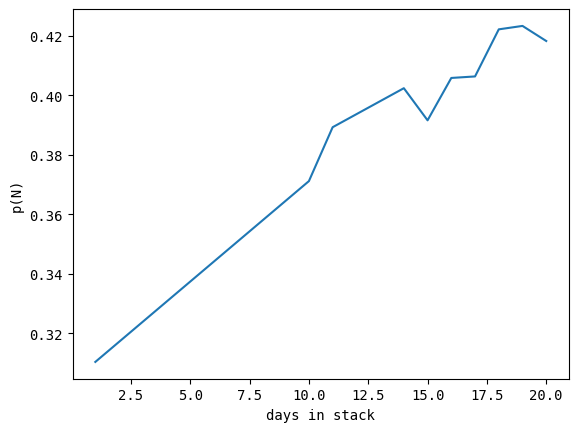

In [349]:
plt.plot(days, p_total)
plt.xlabel('days in stack')
plt.ylabel('p(N)')

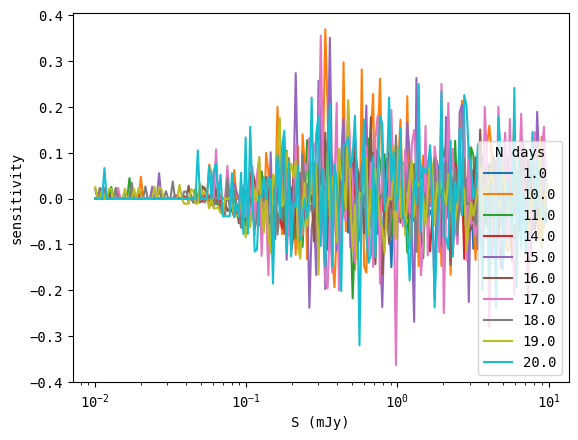

In [350]:
S_idx = 6
S_bins = np.logspace(-2, 1, 200)
S_dev = 10

S_curve = np.zeros((len(data), len(S_bins) - 1))
S_10 = np.zeros(len(data))
S_1 = np.zeros(len(data))
S_err10_up = np.zeros(len(data))
S_err10_down = np.zeros(len(data))
S_err1_up = np.zeros(len(data))
S_err1_down = np.zeros(len(data))

for i in range(len(data)):

    _, S_sens, S_smooth = au.get_sensitivity(
        data[i],
        *(S_idx, S_bins, S_dev)
    )

    plt.plot(S_bins[:-1], S_sens - S_smooth, label = days[i])
    # plt.plot(S_bins[:-1], S_smooth, '--')
    # plt.plot(S_bins[:-1], S_sens - S_smooth, '--')

    S_curve[i] = S_sens
    #S_smooth = gaussian_filter(S_sens, 3)
    S_10[i] = np.max(S_bins[np.where(S_smooth < 0.1)[0]])
    S_1[i] = np.max(S_bins[np.where(S_smooth < 0.01)[0]])
    p_10_idx = np.where(S_smooth < 0.1)[0][-1]
    local_std10 = np.std(S_sens[p_10_idx - 10:p_10_idx + 10])
    S_err10_up[i] = np.max(S_bins[np.where(S_smooth < 0.1 + local_std10)[0]])
    try:
        S_err10_down[i] = np.max(S_bins[np.where(S_smooth < 0.1 - local_std10)[0]])
    except:
        S_err10_down[i] = np.nan
    p_1_idx = np.where(S_smooth < 0.01)[0][-1]
    local_std1 = np.std(S_sens[p_1_idx - 12:p_1_idx + 12])
    S_err1_up[i] = np.max(S_bins[np.where(S_smooth < 0.01 + local_std1)[0]])
    try:
        S_err1_down[i] = np.max(S_bins[np.where(S_smooth < 0.01 - local_std1)[0]])
    except:
        S_err1_down[i] = np.nan

S_err10_down = S_10 - S_err10_down 
S_err10_up -= S_10 
S_err1_down = S_1 - S_err1_down 
S_err1_up -= S_1

#plt.plot(S_bins[:-1], S_sens - S_smooth, label = days[i])
plt.xlabel('S (mJy)')
plt.ylabel('sensitivity')
plt.legend(title = 'N days')
plt.xscale('log')

In [351]:
def analytical_curve_10(x, alpha):

    return S_10[0] * x**alpha

def analytical_curve_1(x, alpha):

    return S_1[0] * x**alpha

alpha_10, err10 = curve_fit(analytical_curve_10, days, S_10, p0 = -0.5, sigma = S_err10_up)
alpha_1, err1 = curve_fit(analytical_curve_1, days, S_1, p0 = alpha_10, sigma = S_err1_up)
print(f'10%: {alpha_10[0]:.2f} +- {err10[0][0]:.3f}')
print(f'1%: {alpha_1[0]:.2f} +- {err1[0][0]:.3f}')

10%: -0.39 +- 0.000
1%: -0.36 +- 0.001


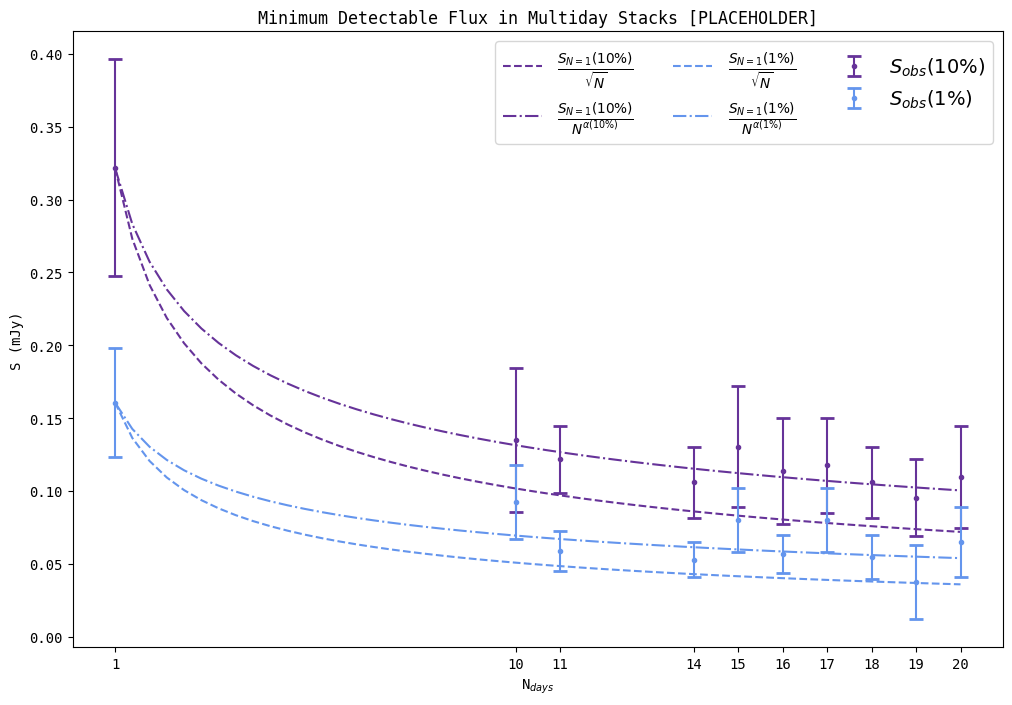

In [353]:
many_days = np.linspace(1, 20)

fig, ax = plt.subplots(figsize = (12, 8))
plt.errorbar(days, S_10, yerr = S_err10_up, label = r'$S_{obs}(10\%)$', color = 'rebeccapurple',
             fmt = '.', capsize=5, capthick=2)
plt.plot(many_days, S_10[0] / np.sqrt(many_days), '--', color = 'rebeccapurple',
         label = r'$\frac{S_{N = 1}(10\%)}{\sqrt{N}}$')
plt.plot(many_days, S_10[0] * many_days**alpha_10, '-.', color = 'rebeccapurple',
         label = r'$\frac{S_{N = 1}(10\%)}{N^{\alpha(10\%)}}$')
plt.errorbar(days, S_1, yerr = S_err1_up, label = r'$S_{obs}(1\%)$', color = 'cornflowerblue',
             fmt = '.', capsize=5, capthick=2)
plt.plot(many_days, S_1[0] / np.sqrt(many_days), '--', color = 'cornflowerblue',
         label = r'$\frac{S_{N=1}(1\%)}{\sqrt{N}}$')
plt.plot(many_days, S_1[0] * many_days**alpha_1, '-.', color = 'cornflowerblue',
         label = r'$\frac{S_{N=1}(1\%)}{N^{\alpha(1\%)}}$')
plt.xlabel(r'N$_{days}$')
plt.ylabel('S (mJy)')
plt.legend(fontsize = 14, ncol = 3)
plt.title('Minimum Detectable Flux in Multiday Stacks [PLACEHOLDER]')
xticks = plt.xticks(days) 